In [1]:
from src.preprocessing import *
from src.sdt import SDT
from src.dbdt import DBDT_SGD
from hmeasure import h_score
import torch
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

Counter({np.int64(1): 284315, np.int64(-1): 492})
sample_size: 10000
Counter({np.int64(1): 9508, np.int64(-1): 492})


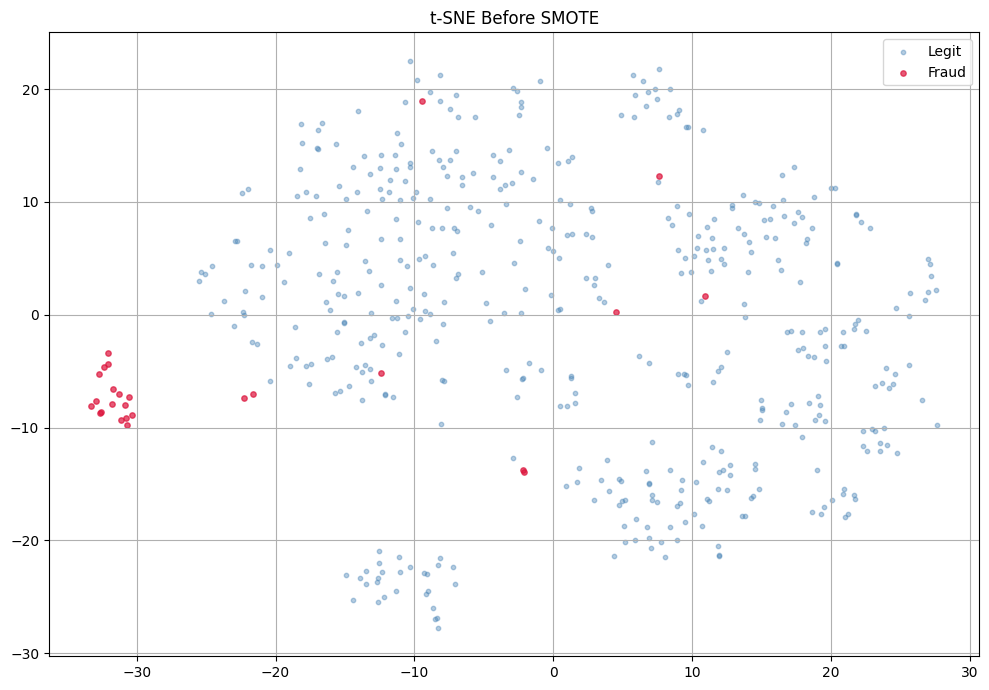

150480
After SMOTE: 286980


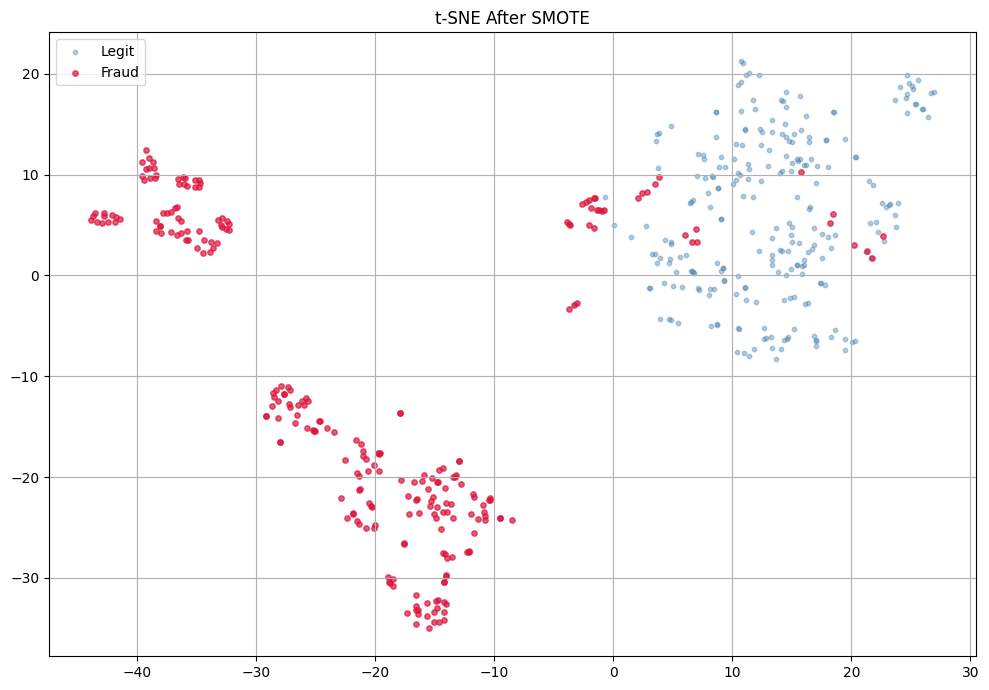

Before SMOTE: {np.int64(-1): np.int64(233), np.int64(1): np.int64(4783)}
After SMOTE: {np.int64(-1): np.int64(4783), np.int64(1): np.int64(4783)}


In [2]:

sample_size = 10000
X, y = load_data()
import collections
print(collections.Counter(y))
if sample_size:
    print(f'sample_size: {sample_size}')
    # separate by class
    fraud_idx = np.where(y == -1)[0]
    legit_idx = np.where(y == 1)[0]

    # take all fraud + random legit
    legit_sample = np.random.choice(legit_idx, size=sample_size - len(fraud_idx), replace=False)
    idx = np.concatenate([fraud_idx, legit_sample])
    np.random.shuffle(idx)

    X = X.iloc[idx]
    y = y[idx]
    print(collections.Counter(y))
    
X_train, X_test, y_train, y_test = test_train_split(X, y)
X_train, X_val, y_train, y_val = train_valid_split(X_train, y_train)
X_train, y_train = interquatile_range(X_train, y_train)
plot_tsne(X=X_train, y=y_train, title="t-SNE Before SMOTE", sample_size=500 if sample_size else 1000) 
unique_before, counts_before = np.unique(y_train, return_counts=True)
feature_size = X_train.size
print(feature_size)



X_train, y_train = apply_smote(X_train, y_train) # resampled
feature_size_smote = X_train.size
print(f"After SMOTE: {feature_size_smote}")
plot_tsne(X=X_train, y=y_train, title="t-SNE After SMOTE", sample_size=500 if sample_size else 1000)
unique_after, counts_after = np.unique(y_train, return_counts=True)

print("Before SMOTE:", dict(zip(unique_before, counts_before)))
print("After SMOTE:", dict(zip(unique_after, counts_after)))

In [3]:
print(feature_size)
print(len(X_train))
print(len(X_val))
print()

150480
9566
1875



# SDT
 
**1. Sigmoid (inner node activation)**
 
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
 
Each inner node MLP outputs a routing probability $p_i \in (0, 1)$ via sigmoid.
 
**2. Left / right path selection**
 
$$
I^l_i + I^r_i = 1
$$
 
Where $I^r_i = 1$ if $p_i > 0.5$ (go right), $I^l_i = 1$ if $p_i < 0.5$ (go left).
 
**3. Leaf node output (binary case)**
 
For binary classification with labels $y \in \{-1, +1\}$, each leaf outputs a scalar $\varphi_\ell \in \mathbb{R}$.
 
In the general multi-class case the softmax is applied:
 
$$
Q^{\ell}_k = \frac{\exp(\varphi^{\ell}_k)}{\sum_{k'} \exp(\varphi^{\ell}_{k'})}
$$
 
Where $\varphi^\ell$ is the learned parameter vector of leaf $\ell$ and $k$ indexes the class.
  
**4. Path probability**
 
$$
\pi_\ell(x \mid \Theta) = \prod_{j < \ell} d_j(x;\Theta_j)^{I^r_j} \cdot (1 - d_j(x;\Theta_j))^{I^l_j}
$$
 
Where:
- $d_j(x; \Theta_j)$ is the sigmoid output of inner node $j$ — i.e. $p_j$
- $I^r_j = 1$ if node $j$ routes right on the path to leaf $\ell$, else $0$
- $I^l_j = 1$ if node $j$ routes left on the path to leaf $\ell$, else $0$
- The product runs over all inner nodes $j$ on the root-to-leaf-$\ell$ path
 
 
**5. SDT predicted output**
 
$$
\hat{y}(x) = \sum_{\ell} \pi_\ell(x \mid \Theta) \cdot \varphi_\ell
$$
 
The final score $h(x) \in \mathbb{R}$. Prediction is the sign:
 
$$
\hat{y} = \text{sign}(h(x)) \in \{-1, +1\}
$$

**6. Tree dimensions**
 
For a tree of depth $d$:
 
$$
\text{inner nodes} = 2^d - 1 \qquad \text{leaf nodes} = 2^d
$$
 


In [4]:
# This is to ensure sdt is running
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_t, X_test_t, y_train_t, y_test_t=torch_cast(X_train, X_test, y_train, y_test, device) # allows for torch shaping
_, X_val_t, _, y_val_t=torch_cast(X_train, X_val, y_train, y_val, device) # allows for torch shaping

"""SDT is not evaluated in the paper. It is not trained on anything, therefore no evaluation. [untrained weights]"""
model = SDT(input_dim=30, depth=4, hidden_dim=30).to(device)
output, path_probs, node_outputs, node_reach = model.forward(X_train_t)
preds =model.predict(X_train_t)
print(preds.shape)
print(preds.unique())


torch.Size([9566])
tensor([-1.,  1.], device='cuda:0')


## Deep Boosting 
**7. Boosting exponential loss**
 
$$
L = \sum_i \exp(-y_i \cdot F(x_i))
$$

 
Where $y_i \in \{-1, +1\}$ and $F(x_i)$ is the ensemble score. Requires $\{-1, +1\}$ labels — loss is asymmetric with $\{0, 1\}$.
 
 
**8. Final ensemble prediction**
 
$$
F_T(x) = \sum_{t=1}^{T} \alpha_t \cdot h_t(x)
$$
 
Where:
- $h_t(x)$ is the output of the $t$-th SDT weak learner
- $\alpha_t$ is the boosting weight of tree $t$
- $T$ is the total number of trees
 

In [5]:

print(torch.cuda.is_available())   # should be True
print(torch.cuda.get_device_name(0))  # should show your RTX 4070

True
NVIDIA GeForce RTX 4070 Laptop GPU


In [6]:
print(X_train_t.device)


cuda:0


In [7]:
epochs = 200
batch_size = 128
model = DBDT_SGD(T=40, input_dim=30, depth=4, hidden_dim=30, lr=0.01, device= device)


In [ ]:

h = model.fit(X_train_t,  y_train_t, epochs=20, batch_size=batch_size)
print(h.device)
# y_pred_train = model.predict(X_train_t).to(device)
# y_pred_test = model.predict(X_test_t).to(device)

Training DBDT:  20%|██        | 4/20 [32:16<2:58:01, 667.59s/it, loss=1214.8591] 

In [ ]:

import time

# time a single batch through a single tree
X_batch = X_train_t[:128]
start = time.time()
for _ in range(100):
    out = model.trees[0].forward(X_batch)
print(f"Single tree forward x100: {time.time() - start:.2f}s")

Single tree forward x100: 0.67s


## Metrics(DBDT SGD)

In [ ]:

metrics = evaluate_binary(y_test_t, model.predict(X_test_t))

: 

: 

: 

: 

: 

AUC:       0.9307
F1:        0.9217
Precision: 0.9907
Recall:    0.8618
H-measure: 0.8491


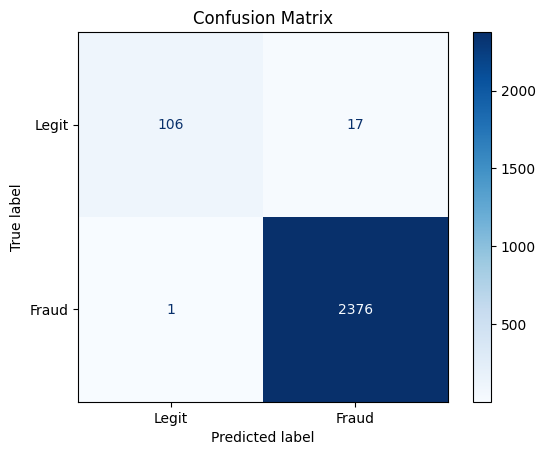

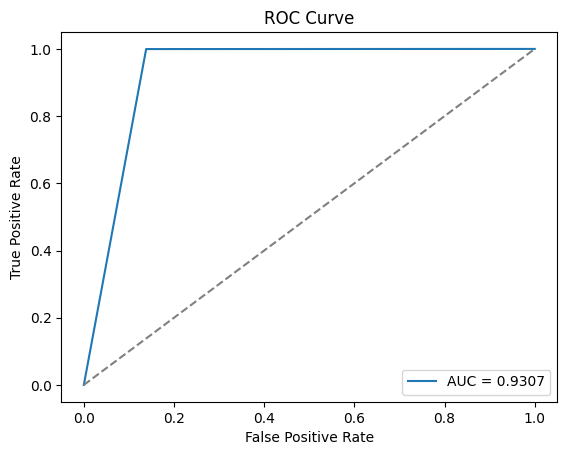

: 

: 

: 

: 

In [ ]:
# 

scores = model.predict_score(X_val_t)
f1_scores = {}
for threshold in np.linspace(-3, 3, 100):
    y_pred = torch.where(scores > threshold, 1, -1)
    # val_metrics = evaluate_binary(y_val_t, )
    f1 = f1_score(y_val_t, y_pred, pos_label=-1, zero_division=0)
    f1_scores[threshold] = f1
print(f1_scores)
min_f1 = 0
min_threshold = -3
for k, v in f1_scores.items():
    if v < min_f1:
        min_f1 = v
        min_threshold = k
        
print(f"Batch size: {batch_size} || sampl: {feature_size_smote} || epochs: {epochs}")
scores = model.predict_score(X_test_t)

y_pred = torch.where(scores > min_threshold, 1, -1)

metrics = evaluate_binary(y_test_t, y_pred)




AUC:       0.9307
F1:        0.9217
Precision: 0.9907
Recall:    0.8618
H-measure: 0.8491

In [ ]:
# print_dataset_size_levels(
#     X_full=X, y_full=y,            # original/full before subset (replace if needed)
#     X_subset=X, y_subset=y,        # your sampled portion (replace if you keep separate vars)
#     X_train=X_train, y_train=y_train,
#     X_val=X_val, y_val=y_val,
#     X_test=X_test, y_test=y_test,
#     X_train_iqr=X_train, y_train_iqr=y_train,  # replace with pre-SMOTE post-IQR vars if different
#     X_train_smote=X_train_resampled, y_train_smote=y_train_resampled
# )

torch.Size([5008, 30])


: 

: 

: 

: 